In [1]:
#from uclmlrepo import fetch_ucirepo


In [2]:
import pandas as pd
import matplotlib .pyplot as plt
import numpy as np
import seaborn as sns
dfloan = pd.read_csv("loan_approval_dataset.csv")
dfloan



,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [3]:
dfloan.head()
print("Head")
dfloan.info()
print("Info")
dfloan.describe()
print("Describe")

Head
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB
Info
Descr

In [4]:
print("Columns")
dfloan.columns
print("shape")
dfloan.shape

Columns
shape


(4269, 13)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


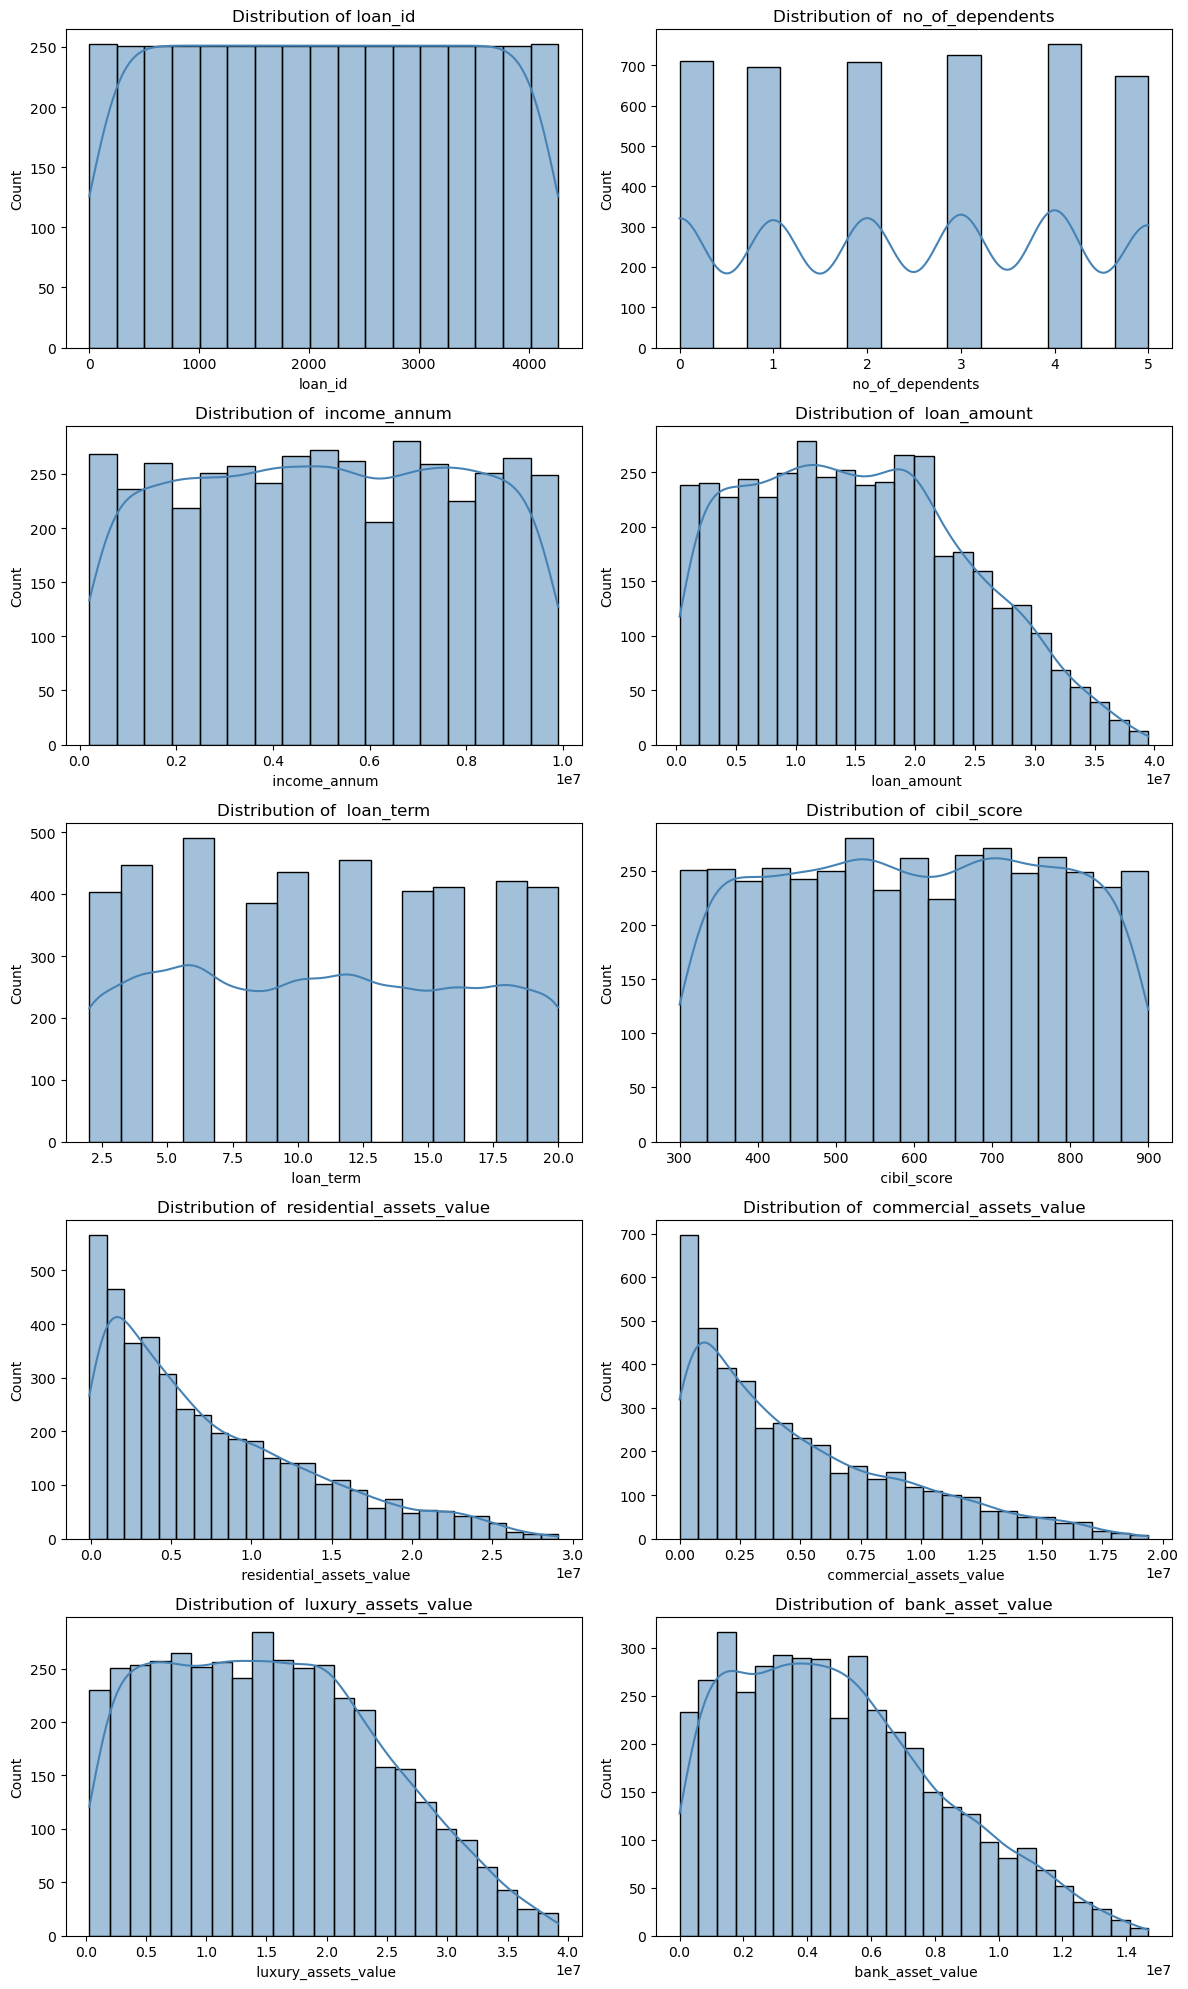

In [5]:
cols = 2
numeric_cols = dfloan.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = dfloan.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
rows = (len(numeric_cols) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]
for i, col in enumerate(numeric_cols):
    sns.histplot(dfloan[col], kde=True, ax=axes[i], color="steelblue", linewidth=1)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
# hide unused axes
for j in range(i+1, len(axes)):
    try:
        fig.delaxes(axes[j])
    except Exception:
        pass
plt.tight_layout()
plt.savefig( "loan_1.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


<function matplotlib.pyplot.show(close=None, block=None)>

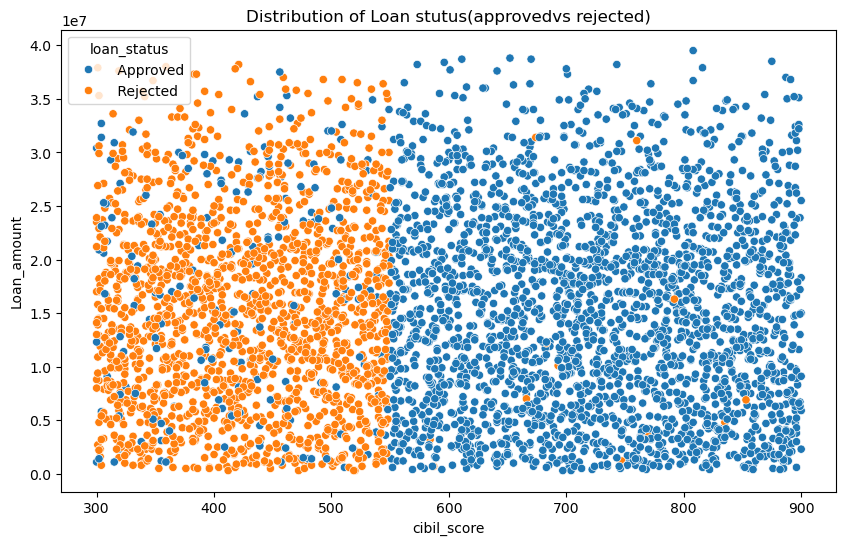

In [7]:

dfloan.columns = dfloan.columns.str.strip()
plt.figure(figsize=(10,6))
sns.scatterplot(x = 'cibil_score',y = 'loan_amount', data=dfloan,hue = 'loan_status')
plt.title("Distribution of Loan stutus(approvedvs rejected)")
plt.ylabel("Loan_amount")
plt.xlabel("cibil_score")
plt.savefig( "loan_2.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show

In [ ]:
#WE can see that Cibil_score is an important parameter, classifying most of the points in approved or rejected.
plt.figure(figsize=(6,4))
sns.heatmap(dfloan[numeric_cols].corr(), annot=True, fmt = ".2f", cmap = "coolwarm")
plt.title("Heatmap of the table")
plt.savefig( "loan_3.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show()

In [ ]:
null_cols = dfloan.columns[dfloan.isnull().any()]
null_rows = dfloan[dfloan[null_cols].isnull().any(axis = 1)]
print("Rows with null values are: ")
print(null_rows)


In [ ]:
sns.histplot(dfloan["loan_term"])
plt.savefig( "loan_4.eps", format="eps", dpi=600, bbox_inches="tight" )
plt.show

In [ ]:
#hypothesis: cibil_score is the key parameter.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
print(dfloan.columns)

In [ ]:
#the cibil_score and loan_status are the key 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
x = dfloan[["cibil_score"]]
y = dfloan[["loan_status"]]
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Predict on both train and test sets
y_pred_train = model.predict(X_train)  
y_pred_test = model.predict(X_test)    

# Accuracy
print("Accuracy Train:", accuracy_score(y_train, y_pred_train))  
print("Accuracy test:", accuracy_score(y_test, y_pred_test))     

In [ ]:
#Thus we can see that cibil score is a valid parameter and 
